# Prophet
Implementación del modelo Prophet de Meta para los cinco activos financieros.
Se comparan los resultados contra ARIMA para establecer el techo de rendimiento de los modelos clásicos antes de pasar a arquitecturas deep learning.

# Importación de librerias y carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.ERROR)

# Ruta relativa al notebook
ruta = Path.cwd().parent / "data"

# Cargar datos procesados
activos = ["eurusd", "gbpusd", "usdjpy", "btc", "eth"]
datos = {}

for activo in activos:
    df = pd.read_csv(ruta / f"../data/{activo}_processed.csv", index_col=0, parse_dates=True)
    datos[activo] = df
    print(f"{activo.upper()}: {len(df)} registros cargados")

EURUSD: 2145 registros cargados
GBPUSD: 2145 registros cargados
USDJPY: 2145 registros cargados
BTC: 3011 registros cargados
ETH: 3011 registros cargados


# Preparación y ejecución de Prophet

In [4]:
# quitamos los logs de cmdstanpy
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

# Prophet sobre todos los activos
resultados_prophet = []

for activo in activos:
    print(f"\nProcesando {activo.upper()}...")
    
    df = datos[activo].copy()
    retornos = df["Retorno"].dropna()
    regimen = df["Regimen"].dropna()
    
    # Split 80/20
    split = int(len(retornos) * 0.8)
    train = retornos.iloc[:split]
    test = retornos.iloc[split:]
    regimen_test = regimen.iloc[split:].reindex(test.index)
    
    # Transformación de los datos al formato de Prophet: columnas ds e y
    df_prophet = pd.DataFrame({
        "ds": train.index,
        "y": train.values
    })
    
    # Entrenar Prophet
    modelo = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False)
    modelo.fit(df_prophet)
    
    # Predecir sobre el periodo test
    futuro = pd.DataFrame({"ds": test.index})
    forecast = modelo.predict(futuro)
    predicciones = forecast["yhat"].values
    
    # Métricas globales
    mae = mean_absolute_error(test.values, predicciones)
    rmse = np.sqrt(mean_squared_error(test.values, predicciones))
    
    resultado = {
        "Activo": activo.upper(),
        "MAE_global": round(mae, 6),
        "RMSE_global": round(rmse, 6),
        "MAE_baja_vol": None,
        "MAE_alta_vol": None,
    }
    
    # Métricas por régimen
    for reg_val, reg_nombre in [("Baja", "baja_vol"), ("Alta", "alta_vol")]:
        mask = regimen_test == reg_val
        if mask.sum() > 0:
            mae_r = mean_absolute_error(test.values[mask], predicciones[mask])
            resultado[f"MAE_{reg_nombre}"] = round(mae_r, 6)
    
    resultados_prophet.append(resultado)
    print(f" MAE: {mae:.6f} | MAE baja: {resultado['MAE_baja_vol']} | MAE alta: {resultado['MAE_alta_vol']}")
   
# Tabla resumen
df_prophet_res = pd.DataFrame(resultados_prophet)
print("\n\nRESUMEN PROPHET - TODOS LOS ACTIVOS")
print("=" * 70)
print(df_prophet_res.to_string(index=False))
   
# Guardar
df_prophet_res.to_csv("../results/prophet_resultados.csv", index=False)
print("\nGuardado en la carpeta resultados/prophet_resultados.csv")
    


Procesando EURUSD...
 MAE: 0.003505 | MAE baja: 0.002902 | MAE alta: 0.004324

Procesando GBPUSD...
 MAE: 0.003611 | MAE baja: 0.003401 | MAE alta: 0.004705

Procesando USDJPY...
 MAE: 0.004954 | MAE baja: 0.003721 | MAE alta: 0.00574

Procesando BTC...
 MAE: 0.017453 | MAE baja: 0.015978 | MAE alta: 0.029372

Procesando ETH...
 MAE: 0.027030 | MAE baja: 0.025179 | MAE alta: 0.035288


RESUMEN PROPHET - TODOS LOS ACTIVOS
Activo  MAE_global  RMSE_global  MAE_baja_vol  MAE_alta_vol
EURUSD    0.003505     0.004763      0.002902      0.004324
GBPUSD    0.003611     0.004647      0.003401      0.004705
USDJPY    0.004954     0.006472      0.003721      0.005740
   BTC    0.017453     0.024804      0.015978      0.029372
   ETH    0.027030     0.038516      0.025179      0.035288

Guardado en la carpeta resultados/prophet_resultados.csv


## Resultados Prophet
Prophet obtiene métricas muy similares a ARIMA en todos los activos. El patrón se mantiene: cripto presenta MAE 5-8x superior al Forex, y la alta volatilidad incrementa el error en ambos tipos de activo. La equivalencia entre ambos modelos clásicos confirma que han alcanzado su techo de rendimiento, justificando el uso de arquitecturas más complejas en las fases siguientes.

# Comparativa ARIMA vs Prophet

In [5]:
df_arima = pd.read_csv("../results/arima_resultados.csv")

comparativa = pd.DataFrame({
    "Activo": df_prophet_res["Activo"],
    "ARIMA_MAE": df_arima["MAE_global"].values,
    "Prophet_MAE": df_prophet_res["MAE_global"].values,
    "ARIMA_MAE_baja": df_arima["MAE_baja_vol"].values,
    "Prophet_MAE_baja": df_prophet_res["MAE_baja_vol"].values,
    "ARIMA_MAE_alta": df_arima["MAE_alta_vol"].values,
    "Prophet_MAE_alta": df_prophet_res["MAE_alta_vol"].values,
    "Mejor_global": ["ARIMA" if a < p else "Prophet"
                     for a, p in zip(df_arima["MAE_global"], df_prophet_res["MAE_global"])]
})

print("COMPARATIVA ARIMA vs PROPHET")
print("=" * 80)
print(comparativa.to_string(index=False))

comparativa.to_csv("../results/comparativa_arima_prophet.csv", index=False)
print("\nGuardado en results/comparativa_arima_prophet.csv")

COMPARATIVA ARIMA vs PROPHET
Activo  ARIMA_MAE  Prophet_MAE  ARIMA_MAE_baja  Prophet_MAE_baja  ARIMA_MAE_alta  Prophet_MAE_alta Mejor_global
EURUSD   0.003498     0.003505        0.002893          0.002902        0.004317          0.004324        ARIMA
GBPUSD   0.003611     0.003611        0.003398          0.003401        0.004707          0.004705      Prophet
USDJPY   0.004947     0.004954        0.003737          0.003721        0.005722          0.005740        ARIMA
   BTC   0.017434     0.017453        0.015968          0.015978        0.029341          0.029372        ARIMA
   ETH   0.026968     0.027030        0.025195          0.025179        0.034948          0.035288        ARIMA

Guardado en results/comparativa_arima_prophet.csv


La tabla muestra que ARIMA y Prophet obtienen métricas prácticamente idénticas en todos los activos, con diferencias en el quinto o sexto decimal. ARIMA supera a Prophet en 4 de 5 activos (EURUSD,USDJPY, BTC, ETH); Prophet únicamente gana en GBPUSD, donde su componente de tendencia captura marginalmente mejor la dinámica del par en el periodo de test. La diferencia entre ambos es mínima. 

Ambos modelos alcanzan su techo de rendimiento: cuando ARIMA obtiene orden (0,0,0) — ruido blanco puro — Prophet tampoco encuentra estructura adicional que explotar. Este resultado justifica el salto a arquitecturas deep learning (LSTM y TFT) en las fases siguientes.

# Visualización comparativa

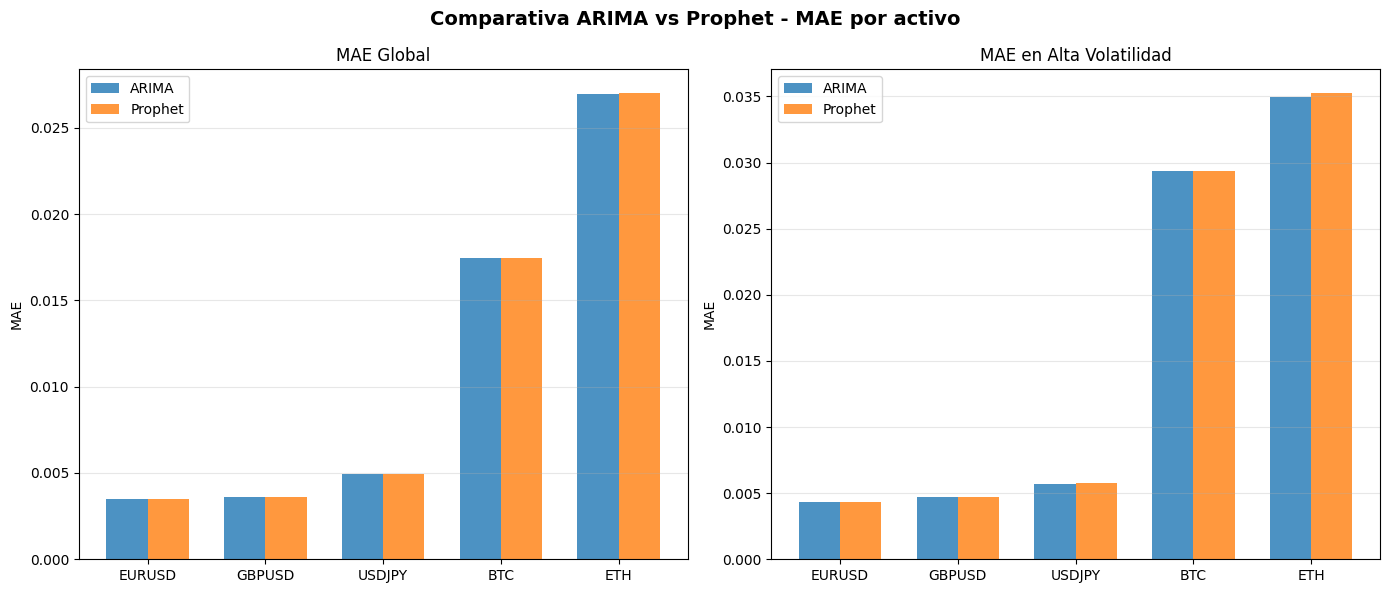

Gráfico guardado en la carpeta results


In [6]:
# Visualización comparativa ARIMA vs Prophet
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Comparativa ARIMA vs Prophet - MAE por activo", fontsize=14, fontweight="bold")

x = np.arange(len(comparativa["Activo"]))
width = 0.35

# MAE global
axes[0].bar(x - width/2, comparativa["ARIMA_MAE"], width, label="ARIMA", color="#1f77b4", alpha=0.8)
axes[0].bar(x + width/2, comparativa["Prophet_MAE"], width, label="Prophet",color="#ff7f0e", alpha=0.8)
axes[0].set_title("MAE Global")
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparativa["Activo"])
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# MAE alta volatilidad
axes[1].bar(x - width/2, comparativa["ARIMA_MAE_alta"], width, label="ARIMA", color="#1f77b4", alpha=0.8)
axes[1].bar(x + width/2, comparativa["Prophet_MAE_alta"], width, label="Prophet", color="#ff7f0e", alpha=0.8)
axes[1].set_title("MAE en Alta Volatilidad")
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparativa["Activo"])
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../results/04_comparativa_arima_prophet.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en la carpeta results")

## Conclusiones:
- ARIMA supera a Prophet en 4 de 5 activos (EURUSD, USDJPY, BTC, ETH), aunque las diferencias son mínimas en el quinto o sexto decimal. Prophet únicamente gana en GBPUSD. Ambos modelos alcanzan el mismo techo de rendimiento para series financieras.
- La brecha cripto vs Forex es enorme y visual: las barras de BTC y ETH son 5-8 veces las de las divisas, tanto en MAE globbal como en alta volatilidad.
- En alta volatilidad el patrón se mantiene: en periodos turbulentos la diferencia entre divisas y cripto se amplía aún más.